### Imports

In [1]:
import random
import warnings

import torch

from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.utils.plotting_utils import visualise_spikes

warnings.filterwarnings('ignore', category=UserWarning)

### Constants

In [2]:
DATASET = DatasetType.SHIPSEAR
FILTERBANK = FilterbankType.MEL

### Visualise spikes

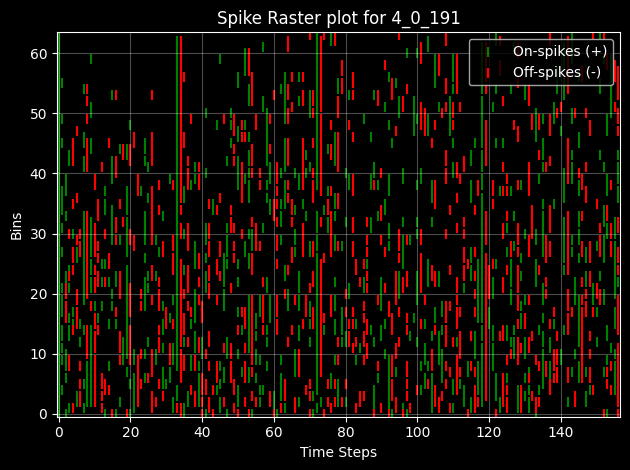

In [3]:
all_files = DATASET.get_spike_dir(FILTERBANK).rglob('*.pt')
random_file = random.choice(list(all_files))
file_name = random_file.stem
spikes = torch.load(random_file)
visualise_spikes(file_name, spikes)

### Confirming input shape

In [4]:
random_sample = DATASET.get_random_sample(FILTERBANK, encoded=True)
print(random_sample.shape)

torch.Size([157, 1, 64])


### Densities

In [5]:
# spikes = torch.load(random_file)   # [T, 1, n_bins] —  already encoded at threshold=0.1
# T, _, n_bins = spikes.shape
# total_possible = T * n_bins
# count = (spikes != 0).sum().item()
# print(f"spike density: {count / total_possible *
# 100:.1f}%  ({count}/{total_possible})")

from collections import defaultdict
import numpy as np

class_densities = defaultdict(list)

for spike_file in DATASET.get_spike_dir(FILTERBANK).rglob('*.pt'):
    class_id = int(spike_file.stem.split('_')[0])
    spikes = torch.load(spike_file)  # [T, 1, n_bins]
    T, _, n_bins = spikes.shape
    total_possible = T * n_bins
    count = (spikes != 0).sum().item()
    class_densities[class_id].append(count / total_possible * 100)

for cls in sorted(class_densities):
    d = class_densities[cls]
    print(f"class {cls}: {np.mean(d):.1f}% ± {np.std(d):.1f}%  (n={len(d)})")

all_d = [v for vs in class_densities.values() for v in vs]
print(f"\noverall: {np.mean(all_d):.1f}% ± {np.std(all_d):.1f}%")

class 0: 9.2% ± 2.4%  (n=369)
class 1: 9.7% ± 5.8%  (n=301)
class 2: 9.6% ± 3.9%  (n=843)
class 3: 8.7% ± 2.5%  (n=486)
class 4: 17.1% ± 4.9%  (n=224)

overall: 10.1% ± 4.5%
